In [2]:
import geopandas as gpd
import pandas as pd


from shapely.ops import unary_union, linemerge
from shapely.geometry import Point, LineString, MultiLineString
from shapely.geometry import mapping


import networkx as nx


import folium
from folium import Map, GeoJson


import json
import mapillary as mly




### Berlin einlesen für Proof of concept

<Axes: >

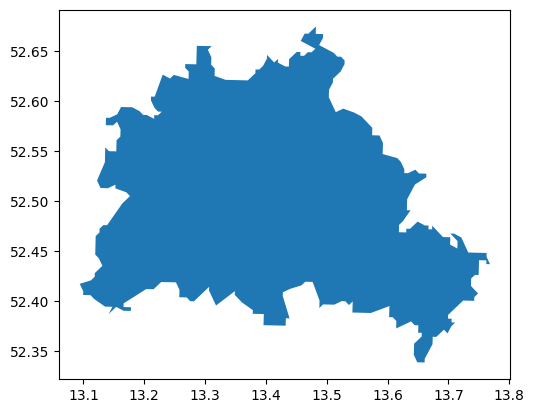

In [3]:
bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
bland_fil=bland[bland["id"].isin(["DE-BE"])]
bland_fil.plot()

### netzwerk einlesen

In [4]:
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_major_highways_germany_250528.geojson.gz")

# use not only the major highways, but all highways for this
#highways=gpd.read_file("../preprocessing/processed_osm_files/processed_almostall_highways_germany_250528.geojson.gz")

crossings=gpd.read_file("../preprocessing/processed_osm_files/processed_crossings_germany_250528.geojson.gz")



In [5]:
crossings

,other_tags,geometry
0,"""bicycle""=>""yes"",""button_operated""=>""yes"",""cro...",POINT (9.97755 53.5493)
1,"""crossing""=>""marked"",""crossing:island""=>""no"",""...",POINT (11.40738 48.17655)
2,"""crossing""=>""uncontrolled"",""crossing:island""=>...",POINT (11.4145 48.15711)
3,"""bicycle""=>""yes"",""crossing""=>""unmarked"",""cross...",POINT (11.43632 48.16963)
4,"""crossing""=>""unmarked"",""highway""=>""crossing"",""...",POINT (11.42891 48.16138)
...,...,...
422583,"""highway""=>""crossing""",POINT (8.20747 53.18849)
422584,"""highway""=>""crossing""",POINT (8.20773 53.18834)
422585,"""crossing""=>""uncontrolled"",""crossing:island""=>...",POINT (8.20843 53.18776)
422586,"""highway""=>""crossing""",POINT (8.20836 53.18798)


In [7]:
# mapillary map feature data: traffic signs einlesen

In [6]:
mapillary_trafficsigns = gpd.read_parquet("../preprocessing/mapillary_map-feature-data_ger_2025-06-07.parquet")
mapillary_trafficsigns

,geometry,first_seen_at,id,last_seen_at,value
0,POINT (5.87278 51.04188),2017-07-26,937460437040493,2017-07-26,regulatory--keep-right--g1
1,POINT (5.87391 51.04213),2022-12-08,2275336505976951,2022-12-08,regulatory--yield--g1
2,POINT (5.87561 51.04201),2017-07-26,509836860046200,2017-07-26,information--bus-stop--g1
3,POINT (5.86728 51.04995),2019-08-19,308753427380748,2019-08-19,regulatory--priority-road--g1
4,POINT (5.87234 51.04163),2017-07-26,230466675518393,2017-07-26,regulatory--stop--g1
...,...,...,...,...,...
5348210,POINT (15.01171 51.24504),2020-08-20,325039229007548,2020-08-20,warning--wild-animals--g1
5348211,POINT (15.01546 51.23665),2020-09-18,793634861524984,2020-09-18,information--general-directions--g1
5348212,POINT (15.01098 51.24377),2020-08-20,505814950843393,2020-08-20,information--general-directions--g1
5348213,POINT (15.01041 51.2371),2020-08-20,300483418247452,2020-08-20,information--general-directions--g1


In [7]:
# Zebra Schilder in Deuscthland filtern
mapillary_trafficsigns_cross=mapillary_trafficsigns[mapillary_trafficsigns.value=="information--pedestrians-crossing--g1"]
mapillary_trafficsigns_cross


,geometry,first_seen_at,id,last_seen_at,value
128,POINT (5.89875 51.01452),2018-05-22,600040478056091,2023-01-29,information--pedestrians-crossing--g1
182,POINT (5.89865 51.01443),2018-05-22,601930787867060,2023-01-29,information--pedestrians-crossing--g1
231,POINT (5.89865 51.01444),2018-05-22,602170441176428,2023-01-29,information--pedestrians-crossing--g1
304,POINT (5.89875 51.01451),2018-05-22,600005078059631,2023-01-29,information--pedestrians-crossing--g1
1924,POINT (5.95915 51.0318),2024-05-07,474510374910004,2024-05-07,information--pedestrians-crossing--g1
...,...,...,...,...,...
5347936,POINT (15.00257 51.15023),2023-11-07,880673816768387,2023-11-07,information--pedestrians-crossing--g1
5347969,POINT (15.00374 51.15062),2016-08-30,817429889125041,2024-04-20,information--pedestrians-crossing--g1
5347970,POINT (14.98883 51.15074),2022-06-24,160860189989516,2022-06-24,information--pedestrians-crossing--g1
5348022,POINT (15.00563 51.15178),2022-06-22,134534665920398,2022-06-22,information--pedestrians-crossing--g1


In [8]:
# Baustellen ausschließen (werden aber vermutlich auch "gute" aussprtiert)

from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

df_2years = mapillary_trafficsigns_cross[
    mapillary_trafficsigns_cross.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 24, axis=1)
]


<Axes: >

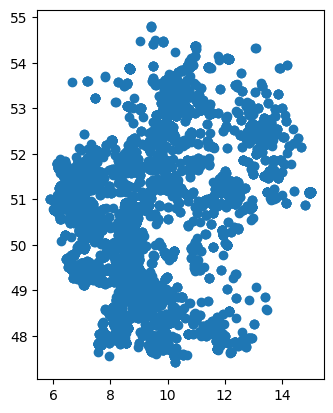

In [9]:
df_2years.plot()

In [10]:
df_2years

,geometry,first_seen_at,id,last_seen_at,value
128,POINT (5.89875 51.01452),2018-05-22,600040478056091,2023-01-29,information--pedestrians-crossing--g1
182,POINT (5.89865 51.01443),2018-05-22,601930787867060,2023-01-29,information--pedestrians-crossing--g1
231,POINT (5.89865 51.01444),2018-05-22,602170441176428,2023-01-29,information--pedestrians-crossing--g1
304,POINT (5.89875 51.01451),2018-05-22,600005078059631,2023-01-29,information--pedestrians-crossing--g1
2939,POINT (5.9975 50.99272),2014-11-26,217625300129370,2023-01-05,information--pedestrians-crossing--g1
...,...,...,...,...,...
5347375,POINT (15.00687 51.15143),2018-09-20,140185484751831,2022-06-22,information--pedestrians-crossing--g1
5347454,POINT (15.00266 51.14967),2018-07-04,3997383676963958,2024-04-20,information--pedestrians-crossing--g1
5347738,POINT (15.00398 51.15084),2016-09-13,171195341472685,2022-08-08,information--pedestrians-crossing--g1
5347826,POINT (15.00301 51.15044),2021-12-16,1788950058152361,2024-04-20,information--pedestrians-crossing--g1


In [12]:
mapillary_trafficsigns_cross_buffered = df_2years.to_crs(25833).copy()
mapillary_trafficsigns_cross_buffered["geometry"] = mapillary_trafficsigns_cross_buffered.geometry.buffer(40)
mapillary_trafficsigns_cross_buffered = mapillary_trafficsigns_cross_buffered.to_crs(df_2years.crs)
mapillary_trafficsigns_cross_buffered

,geometry,first_seen_at,id,last_seen_at,value
128,"POLYGON ((5.89931 51.01457, 5.89931 51.01453, ...",2018-05-22,600040478056091,2023-01-29,information--pedestrians-crossing--g1
182,"POLYGON ((5.89921 51.01448, 5.89922 51.01444, ...",2018-05-22,601930787867060,2023-01-29,information--pedestrians-crossing--g1
231,"POLYGON ((5.89921 51.01449, 5.89922 51.01445, ...",2018-05-22,602170441176428,2023-01-29,information--pedestrians-crossing--g1
304,"POLYGON ((5.89931 51.01456, 5.89932 51.01452, ...",2018-05-22,600005078059631,2023-01-29,information--pedestrians-crossing--g1
2939,"POLYGON ((5.99806 50.99276, 5.99807 50.99273, ...",2014-11-26,217625300129370,2023-01-05,information--pedestrians-crossing--g1
...,...,...,...,...,...
5347375,"POLYGON ((15.00744 51.15143, 15.00744 51.15139...",2018-09-20,140185484751831,2022-06-22,information--pedestrians-crossing--g1
5347454,"POLYGON ((15.00323 51.14967, 15.00323 51.14963...",2018-07-04,3997383676963958,2024-04-20,information--pedestrians-crossing--g1
5347738,"POLYGON ((15.00455 51.15084, 15.00455 51.15081...",2016-09-13,171195341472685,2022-08-08,information--pedestrians-crossing--g1
5347826,"POLYGON ((15.00358 51.15044, 15.00358 51.1504,...",2021-12-16,1788950058152361,2024-04-20,information--pedestrians-crossing--g1


In [13]:
not_intersected = gpd.sjoin(
    mapillary_trafficsigns_cross_buffered, 
    crossings, 
    how="left", 
    predicate="intersects"
)
not_intersected = not_intersected[not_intersected["index_right"].isna()]


In [14]:
not_intersected

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags
3208,"POLYGON ((5.99173 50.78433, 5.99173 50.78429, ...",2015-08-03,811940396371858,2024-08-05,information--pedestrians-crossing--g1,NaN,NaN
8084,"POLYGON ((6.05109 50.91839, 6.05109 50.91835, ...",1970-01-01,4035910386731121,2024-07-20,information--pedestrians-crossing--g1,NaN,NaN
8129,"POLYGON ((6.05398 50.91778, 6.05398 50.91774, ...",1970-01-01,1694067454805652,2023-08-03,information--pedestrians-crossing--g1,NaN,NaN
8135,"POLYGON ((6.05582 50.91695, 6.05582 50.91691, ...",1970-01-01,649923534452199,2023-07-07,information--pedestrians-crossing--g1,NaN,NaN
8215,"POLYGON ((6.05075 50.91834, 6.05075 50.9183, 6...",2015-04-18,818044232419148,2018-05-09,information--pedestrians-crossing--g1,NaN,NaN
...,...,...,...,...,...,...,...
5279840,"POLYGON ((14.08424 51.7792, 14.08423 51.77917,...",2021-09-10,896139401337793,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5279842,"POLYGON ((14.08425 51.77922, 14.08425 51.77919...",2021-09-10,896139394671127,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5340202,"POLYGON ((14.94903 51.14557, 14.94903 51.14553...",2014-12-25,321271559634853,2021-06-22,information--pedestrians-crossing--g1,NaN,NaN
5345860,"POLYGON ((15.0021 51.15027, 15.0021 51.15023, ...",2016-08-29,204208367990779,2024-04-20,information--pedestrians-crossing--g1,NaN,NaN


In [30]:
#not_intersected.explore()

In [17]:
not_intersected_recent = not_intersected[not_intersected["last_seen_at"] > "2022-01-01"]
not_intersected_recent

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags
3208,"POLYGON ((5.99173 50.78433, 5.99173 50.78429, ...",2015-08-03,811940396371858,2024-08-05,information--pedestrians-crossing--g1,NaN,NaN
8084,"POLYGON ((6.05109 50.91839, 6.05109 50.91835, ...",1970-01-01,4035910386731121,2024-07-20,information--pedestrians-crossing--g1,NaN,NaN
8129,"POLYGON ((6.05398 50.91778, 6.05398 50.91774, ...",1970-01-01,1694067454805652,2023-08-03,information--pedestrians-crossing--g1,NaN,NaN
8135,"POLYGON ((6.05582 50.91695, 6.05582 50.91691, ...",1970-01-01,649923534452199,2023-07-07,information--pedestrians-crossing--g1,NaN,NaN
8369,"POLYGON ((6.0526 50.91892, 6.0526 50.91888, 6....",2014-12-08,934397443983129,2024-05-28,information--pedestrians-crossing--g1,NaN,NaN
...,...,...,...,...,...,...,...
5279771,"POLYGON ((14.08439 51.77926, 14.08439 51.77922...",2021-09-10,896139398004460,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5279840,"POLYGON ((14.08424 51.7792, 14.08423 51.77917,...",2021-09-10,896139401337793,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5279842,"POLYGON ((14.08425 51.77922, 14.08425 51.77919...",2021-09-10,896139394671127,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5345860,"POLYGON ((15.0021 51.15027, 15.0021 51.15023, ...",2016-08-29,204208367990779,2024-04-20,information--pedestrians-crossing--g1,NaN,NaN


In [18]:
not_intersected_recent.explore(tiles="CartoDB positron")

In [19]:
# Baustellen ausschließen (werden aber vermutlich auch "gute" aussprtiert)

from datetime import datetime

def months_between(date1, date2):
    d1 = datetime.strptime(date1, "%Y-%m-%d")
    d2 = datetime.strptime(date2, "%Y-%m-%d")
    return abs((d2.year - d1.year) * 12 + d2.month - d1.month)

not_intersected_recent_36months = not_intersected_recent[
    not_intersected_recent.apply(lambda row: months_between(row['first_seen_at'], row['last_seen_at']) >= 36, axis=1)
]

In [20]:
not_intersected_recent_36months

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags
3208,"POLYGON ((5.99173 50.78433, 5.99173 50.78429, ...",2015-08-03,811940396371858,2024-08-05,information--pedestrians-crossing--g1,NaN,NaN
8084,"POLYGON ((6.05109 50.91839, 6.05109 50.91835, ...",1970-01-01,4035910386731121,2024-07-20,information--pedestrians-crossing--g1,NaN,NaN
8129,"POLYGON ((6.05398 50.91778, 6.05398 50.91774, ...",1970-01-01,1694067454805652,2023-08-03,information--pedestrians-crossing--g1,NaN,NaN
8135,"POLYGON ((6.05582 50.91695, 6.05582 50.91691, ...",1970-01-01,649923534452199,2023-07-07,information--pedestrians-crossing--g1,NaN,NaN
8369,"POLYGON ((6.0526 50.91892, 6.0526 50.91888, 6....",2014-12-08,934397443983129,2024-05-28,information--pedestrians-crossing--g1,NaN,NaN
...,...,...,...,...,...,...,...
5279771,"POLYGON ((14.08439 51.77926, 14.08439 51.77922...",2021-09-10,896139398004460,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5279840,"POLYGON ((14.08424 51.7792, 14.08423 51.77917,...",2021-09-10,896139401337793,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5279842,"POLYGON ((14.08425 51.77922, 14.08425 51.77919...",2021-09-10,896139394671127,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN
5345860,"POLYGON ((15.0021 51.15027, 15.0021 51.15023, ...",2016-08-29,204208367990779,2024-04-20,information--pedestrians-crossing--g1,NaN,NaN


In [21]:
not_intersected_recent_36months.explore(tiles="CartoDB positron")

---> Es ist einfach zu anfällig für Baustellen, die nicht mehr existieren.

In [ ]:
################################

In [108]:
## retrieve the image ID for the map features

In [22]:
### this takes 0.5s per image ID, TODO: would be nice to have tqdm at some point so see the progress

from tqdm import tqdm
tqdm.pandas()  # aktiviert tqdm für .progress_apply()


# Load the token from JSON config file
with open("../preprocessing/config_mapillary_privat.json", "r") as f:
    config = json.load(f)

# Set the token
access_token = config["ACCESS_TOKEN"]
mly.interface.set_access_token(access_token)



def get_image_id(map_feature_id):
    feature_str = mly.interface.feature_from_key(key=str(map_feature_id))
    feature = json.loads(feature_str)
    images = feature["features"]["properties"]["images"]["data"]
    return images[-1]["id"] if images else None

import logging

# Setze alle aktiven Logger auf WARNING oder ERROR
for name in logging.root.manager.loggerDict:
    logging.getLogger(name).setLevel(logging.WARNING)

# Optional: Basis-Logging-Level generell auf ERROR setzen
logging.basicConfig(level=logging.ERROR)


not_intersected_recent_36months["image_id"] = not_intersected_recent_36months["id"].progress_apply(get_image_id)


100%|██████████| 420/420 [06:47<00:00,  1.03it/s]
/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [23]:
not_intersected_recent_36months

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags,image_id
3208,"POLYGON ((5.99173 50.78433, 5.99173 50.78429, ...",2015-08-03,811940396371858,2024-08-05,information--pedestrians-crossing--g1,NaN,NaN,621230338834097
8084,"POLYGON ((6.05109 50.91839, 6.05109 50.91835, ...",1970-01-01,4035910386731121,2024-07-20,information--pedestrians-crossing--g1,NaN,NaN,697166122875531
8129,"POLYGON ((6.05398 50.91778, 6.05398 50.91774, ...",1970-01-01,1694067454805652,2023-08-03,information--pedestrians-crossing--g1,NaN,NaN,1334858194447388
8135,"POLYGON ((6.05582 50.91695, 6.05582 50.91691, ...",1970-01-01,649923534452199,2023-07-07,information--pedestrians-crossing--g1,NaN,NaN,956748826281470
8369,"POLYGON ((6.0526 50.91892, 6.0526 50.91888, 6....",2014-12-08,934397443983129,2024-05-28,information--pedestrians-crossing--g1,NaN,NaN,3965955250164326
...,...,...,...,...,...,...,...,...
5279771,"POLYGON ((14.08439 51.77926, 14.08439 51.77922...",2021-09-10,896139398004460,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,1227132181066137
5279840,"POLYGON ((14.08424 51.7792, 14.08423 51.77917,...",2021-09-10,896139401337793,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,381234590073638
5279842,"POLYGON ((14.08425 51.77922, 14.08425 51.77919...",2021-09-10,896139394671127,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,381234590073638
5345860,"POLYGON ((15.0021 51.15027, 15.0021 51.15023, ...",2016-08-29,204208367990779,2024-04-20,information--pedestrians-crossing--g1,NaN,NaN,806514083619712


In [24]:
sc5_poly=not_intersected_recent_36months.copy()


In [25]:
sc5_poly.to_file("scenario5_crossing-missing_polys.fgb", driver="FlatGeobuf")

In [26]:
sc5_centroids = sc5_poly.copy()
sc5_centroids=sc5_centroids.to_crs(25832)
sc5_centroids["geometry"] = sc5_centroids.geometry.centroid
sc5_centroids=sc5_centroids.to_crs(4326)

sc5_centroids

,geometry,first_seen_at,id,last_seen_at,value,index_right,other_tags,image_id
3208,POINT (5.99117 50.78428),2015-08-03,811940396371858,2024-08-05,information--pedestrians-crossing--g1,NaN,NaN,621230338834097
8084,POINT (6.05053 50.91834),1970-01-01,4035910386731121,2024-07-20,information--pedestrians-crossing--g1,NaN,NaN,697166122875531
8129,POINT (6.05341 50.91773),1970-01-01,1694067454805652,2023-08-03,information--pedestrians-crossing--g1,NaN,NaN,1334858194447388
8135,POINT (6.05526 50.9169),1970-01-01,649923534452199,2023-07-07,information--pedestrians-crossing--g1,NaN,NaN,956748826281470
8369,POINT (6.05203 50.91888),2014-12-08,934397443983129,2024-05-28,information--pedestrians-crossing--g1,NaN,NaN,3965955250164326
...,...,...,...,...,...,...,...,...
5279771,POINT (14.08381 51.77925),2021-09-10,896139398004460,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,1227132181066137
5279840,POINT (14.08366 51.7792),2021-09-10,896139401337793,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,381234590073638
5279842,POINT (14.08367 51.77922),2021-09-10,896139394671127,2024-09-17,information--pedestrians-crossing--g1,NaN,NaN,381234590073638
5345860,POINT (15.00153 51.15027),2016-08-29,204208367990779,2024-04-20,information--pedestrians-crossing--g1,NaN,NaN,806514083619712


In [27]:
sc5_centroids.to_file("scenario5_crossing-missing_points.fgb", driver="FlatGeobuf")

In [28]:
def fgb_to_pmtiles_dual_layer(points_fgb, polys_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path

    tmp_points = "tmp_points.pmtiles"
    tmp_polys = "tmp_polys.pmtiles"

    subprocess.run([
        "tippecanoe", "-o", tmp_points,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tippecanoe", "-o", tmp_polys,
        f"--layer={layer_name}-polys",
        "--minimum-zoom=14", "--maximum-zoom=15",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        str(Path(polys_fgb).resolve())
    ], check=True)

    subprocess.run([
        "tile-join", "--force", "-o", str(Path(output_pmtiles).resolve()),
        tmp_points, tmp_polys
    ], check=True)

    print("✅ Combined PMTiles created")


In [29]:
fgb_to_pmtiles_dual_layer(
    points_fgb="scenario5_crossing-missing_points.fgb",
    polys_fgb="scenario5_crossing-missing_polys.fgb",
    output_pmtiles="scenario5_crossing-missing.pmtiles",
    layer_name="scenario5"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
420 features, 18885 bytes of geometry and attributes, 21605 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8636/5648  
detected indexed FlatGeobuf: assigning feature IDs by sequence
420 features, 100055 bytes of geometry and attributes, 21652 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  15/17173/11099  


✅ Combined PMTiles created
